In [ ]:
import sys
sys.path.append('..')

import random
import pickle as pkl
import matplotlib.pyplot as plt 
from collections import defaultdict
from tensorflow.keras.models import load_model

from lib_dolphin.audio import * 
from lib_dolphin.parameters import *
from lib_dolphin.features import * 

In [13]:
classifier = load_model('static/web_service/ml_models_v3/supervised.h5')
classifier.summary()

Model: "model_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_23 (InputLayer)       [(None, 36, 130, 1)]      0         
                                                                 
 model_1 (Functional)        (None, 128)               574176    
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 5)                 645       
                                                                 
Total params: 574,821
Trainable params: 574,821
Non-trainable params: 0
_________________________________________________________________


In [11]:
labels = pkl.load(open('static/web_service/ml_models_v3/labels.pkl', 'rb'))
reverse = {v:k for k, v in labels.items()}

In [ ]:
df = pd.read_csv('../datasets/l2.csv')
audio     = raw('../datasets/l2.wav')
instances = []
data = {k:[] for k, v in reverse.items()}
data[-1] = []
data[-2] = []
inst  = 0 
for _, row in df.iterrows():
    start = row['starts']
    stop  = row['stops']
    w     = audio[start:stop]
    if len(w) > 0:
        s = spectrogram(w, FFT_LO, FFT_HI, FFT_WIN, FFT_STEP)
        b = s[0:-(len(s) % 36),:]
        x = b.reshape((len(b) // 36, 36, 130, 1))
        if(len(x) > 0):
            if inst % 10 == 0:
                print(f"{inst} / {len(df)}= {inst / len(df)}% ")
            p = classifier.predict(x, verbose=0)

            for t, row in enumerate(p): 
                for i in range(0,5):
                    data[i].append(row[i])
                data[-1].append(start + (t * 36 * FFT_STEP))
                data[-2].append(inst)
    inst += 1

In [141]:
reverse[-1] = 'sample'
reverse[-2] = 'instance'
df = pd.DataFrame({reverse[k] : v for k, v in data.items()})

In [142]:
df.to_csv('l2_labels.csv', index=None)

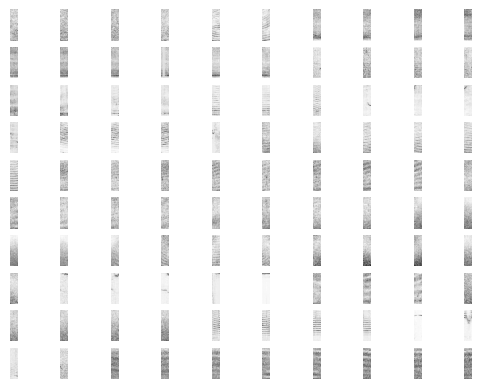

In [160]:
x = raw('../datasets/l2.wav')
i = 1
for sample in df[df['BURST'] > 0.25][-100:]['sample']:
    start = sample
    stop  = start + 36 * FFT_STEP
    s     = spectrogram(x[start:stop], FFT_LO, FFT_HI, FFT_WIN, FFT_STEP)
    
    plt.subplot(10, 10, i)
    plt.imshow(1.0 - s.T, cmap='gray')
    plt.axis('off')

    i += 1
plt.savefig('l1_dataset.png', bbox_inches='tight')